# Calibration gradients & the Hessian (HK)

Calibration recovers the detector's optical parameters (scattering, absorption, reflection, QE)
by **descending a smooth loss**. This notebook opens up *why* that works, on HK geometry:

1. **Gradient** — the loss landscape over the optical parameters (smooth, minimum at truth).
2. **Hessian** — the curvature = Fisher information: which parameters are well-constrained,
   which are degenerate, and the achievable uncertainty (Cramér–Rao bound).
3. **Before / after** — the state of the fit before it starts vs after it converges.

Sources are real HK injector positions/directions (`UKLIinfo/LightInjectorsDetails.json`,
some ID diffusers, all built from the same loaded `WarwickDA02` measured profile via
`measured_profile_source`) rather than the idealized laser/isotropic sources the
`tutorials/` version uses.

The GPU work (sims, sweeps, fit, Fisher) runs in `calibration_gradients_job.py` as a
standalone process so the CUDA context / JAX preallocated GPU memory pool is released on
exit, instead of being pinned to this notebook's kernel. This notebook only loads the saved
`.npz` and plots — plots are notebook content.

> Note: the sweep cells visualize `WC_smooth_loss`; the `fit()`/`crb()` calls use `lucid.fitting`'s own √-MSE Gauss-Newton objective internally — two related but distinct loss forms.

In [61]:
import sys

!{sys.executable} calibration_gradients_job.py --gpu 2 --frac 0 --out dif_more.npz


[CudaDevice(id=0)]
gpu
[time] setup: detector, sources, simulator ...
scenario hk, optics wcsim: sources ['dif0', 'dif1', 'dif2', 'dif3', 'dif4', 'dif5', 'dif6', 'dif7', 'dif8', 'dif9', 'dif10', 'dif11', 'dif12', 'dif13', 'dif14', 'dif15', 'dif16', 'dif17', 'dif18', 'dif19', 'dif20', 'dif21', 'dif22', 'dif23', 'dif24', 'dif25', 'dif26', 'dif27', 'dif28', 'dif32'], reflection model scalar
[time] setup: detector, sources, simulator: 31.0 s
[time] build_calibration_problem: truth charge for 30 sources (incl. JIT) ...
[time] build_calibration_problem: truth charge for 30 sources (incl. JIT): 5.0 s
19746 PMTs | 30 calibration sources | 7 global parameters
[time] sweep setup: truth events for 30 sources + loss/grad JIT warm-up ...
[time] sweep setup: truth events for 30 sources + loss/grad JIT warm-up: 40.3 s
[time] 1D sweeps ...
QE: 100%|███████████████████████████████████████| 41/41 [01:44<00:00,  2.56s/it]
[time] 1D sweeps: 419.6 s

per-source sweep minimum (AD-gradient zero crossing) as 

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

r = np.load('dif_more.npz')
FIELDS = list(r['fields'])
NS = int(r['ns'])
has_1d, has_2d = 'sweep1d_order' in r.files, 'losses2d_src' in r.files   # depends on --sweeps
sweep1d_order = list(r['sweep1d_order']) if has_1d else []
source_labels = list(r['source_labels']) if 'source_labels' in r.files else []
print(f'{NS} PMTs | {len(FIELDS)} global parameters | sweeps run: 1D {has_1d}, 2D {has_2d}')

19746 PMTs | 7 global parameters | sweeps run: 1D True, 2D False


## 1. Gradient — the loss landscape
Sweep each optical parameter around truth and plot the loss (top) with its **automatic-
differentiation gradient** vs the finite-difference gradient (bottom). The loss is smooth and
minimised at truth; AD matches FD.

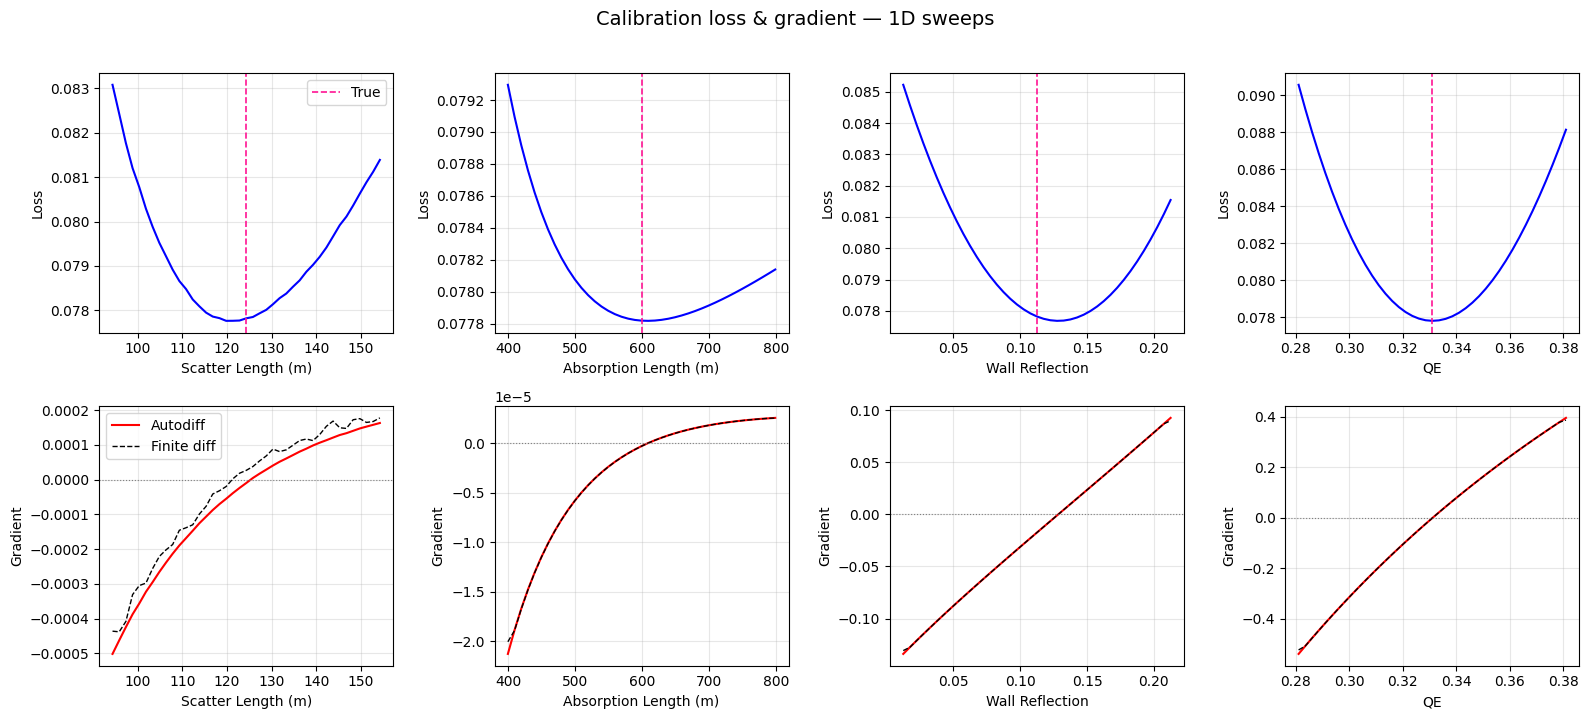

In [69]:
if not has_1d:
    print('no 1D sweeps in this run (--sweeps none)')
else:
    n = len(sweep1d_order)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 7), squeeze=False)
    for col, key in enumerate(sweep1d_order):
        values, losses = r[f'{key}_values'], r[f'{key}_losses']
        gradients, numerical_grads = r[f'{key}_gradients'], r[f'{key}_numerical_grads']
        center, label = float(r[f'{key}_center']), str(r[f'{key}_label'])
        ax_loss, ax_grad = axes[0, col], axes[1, col]
        ax_loss.plot(values, losses, 'b-', linewidth=1.5)
        ax_loss.axvline(center, color='deeppink', ls='--', lw=1.2, label='True')
        ax_loss.set_xlabel(label); ax_loss.set_ylabel('Loss'); ax_loss.grid(alpha=0.3)
        if col == 0: ax_loss.legend()
        ax_grad.plot(values, gradients, 'r-', linewidth=1.5, label='Autodiff')
        ax_grad.plot(values, numerical_grads, 'k--', linewidth=1.0, label='Finite diff')
        ax_grad.axhline(0, color='gray', ls=':', lw=0.8)
        ax_grad.set_xlabel(label); ax_grad.set_ylabel('Gradient'); ax_grad.grid(alpha=0.3)
        if col == 0: ax_grad.legend()
    fig.suptitle('Calibration loss & gradient — 1D sweeps', fontsize=14, y=1.02)
    fig.tight_layout(); plt.show()

### Per source
The landscape above is the mean over all sources. Below, each source's own loss (normalised to its
own range, collimators dashed) and where its autodiff gradient crosses zero, as an offset from truth.
A source whose minimum sits away from truth is pulling the combined fit.

In [63]:
def zero_crossing(x, g):
    for i in range(len(g) - 1):
        if g[i] == 0:
            return x[i]
        if g[i] * g[i + 1] < 0:
            return x[i] - g[i] * (x[i + 1] - x[i]) / (g[i + 1] - g[i])
    return np.nan

BEAM = ('col', 'las')   # collimator / laser labels; drawn dashed

if not has_1d:
    print('no 1D sweeps in this run (--sweeps none)')
else:
    n = len(sweep1d_order)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.8), squeeze=False)
    for col, key in enumerate(sweep1d_order):
        ax, values = axes[0, col], r[f'{key}_values']
        for s, lab in enumerate(source_labels):
            d = r[f'{key}_src_losses'][s] - np.nanmin(r[f'{key}_src_losses'][s])
            ax.plot(values, d / np.nanmax(d), ls='--' if lab.startswith(BEAM) else '-', lw=1.2, label=lab)
        ax.axvline(float(r[f'{key}_center']), color='deeppink', ls=':', lw=1.2)
        ax.set_xlabel(str(r[f'{key}_label'])); ax.set_ylabel('normalised ΔLoss'); ax.grid(alpha=0.3)
    axes[0, 0].legend(fontsize=7, ncol=2)
    fig.suptitle('Per-source loss landscapes (each normalised to its own range)', fontsize=13, y=1.03)
    fig.tight_layout(); plt.show()

    print('sweep minimum (AD-gradient zero crossing) as offset from truth; nan = none in range')
    print(f'{"source":10s}' + ''.join(f'{k:>24s}' for k in sweep1d_order))
    for s, lab in list(enumerate(source_labels)) + [(None, 'mean')]:
        cells = ''
        for key in sweep1d_order:
            g = r[f'{key}_gradients'] if s is None else r[f'{key}_src_gradients'][s]
            cells += f'{zero_crossing(r[f"{key}_values"], g) / float(r[f"{key}_center"]) - 1:+24.1%}'
        print(f'{lab:10s}{cells}')

no 1D sweeps in this run (--sweeps none)


### 2D landscape — a parameter degeneracy
Absorption length and QE trade off (both scale the detected light), so their 2D loss surface
has a **valley** — the calibration analog of a degenerate direction.

In [64]:
if not has_2d:
    print('no 2D sweep in this run (--sweeps none or 1d)')
else:
    x2d, y2d, losses2d = r['x2d_values'], r['y2d_values'], r['losses2d']
    gradx2d, grady2d = r['gradx2d'], r['grady2d']
    x2d_label, y2d_label = str(r['x2d_label']), str(r['y2d_label'])
    x2d_center, y2d_center = float(r['x2d_center']), float(r['y2d_center'])
    x2d_grad_scale, y2d_grad_scale = float(r['x2d_grad_scale']), float(r['y2d_grad_scale'])

    delta = losses2d - np.nanmin(losses2d) + 1e-6
    vmax = float(np.nanpercentile(delta, 95)); vmin = min(1e-1, vmax * 0.01)
    extent = [float(x2d[0]), float(x2d[-1]), float(y2d[0]), float(y2d[-1])]

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(delta.T, extent=extent, origin='lower', aspect='auto', cmap='viridis',
                   norm=LogNorm(vmin=vmin, vmax=vmax))

    U, V = -gradx2d * x2d_grad_scale, -grady2d * y2d_grad_scale
    norm = np.sqrt(U ** 2 + V ** 2) + 1e-10
    x_stream = np.linspace(extent[0], extent[1], len(x2d)); y_stream = np.linspace(extent[2], extent[3], len(y2d))
    ax.streamplot(x_stream, y_stream, (U / norm).T, (V / norm).T, color='white', density=1.0, linewidth=0.7, arrowsize=0.5)

    ax.plot(x2d_center, y2d_center, '*', color='deeppink', markersize=20, markeredgecolor='white', markeredgewidth=0.5)
    ax.set_xlabel(x2d_label); ax.set_ylabel(y2d_label)
    ax.set_title('Absorption length x QE — degeneracy valley')
    fig.colorbar(im, ax=ax, pad=0.02, label='ΔLoss')
    fig.tight_layout(); plt.show()

no 2D sweep in this run (--sweeps none or 1d)


In [65]:
if not has_2d:
    print('no 2D sweep in this run (--sweeps none or 1d)')
else:
    L2 = r['losses2d_src']
    ncol = 5; nrow = int(np.ceil(len(source_labels) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.9 * nrow), squeeze=False)
    for s, lab in enumerate(source_labels):
        ax = axes[s // ncol, s % ncol]
        d = L2[s] - np.nanmin(L2[s]) + 1e-6
        hi = float(np.nanpercentile(d, 95))
        ax.imshow(d.T, extent=extent, origin='lower', aspect='auto', cmap='viridis',
                  norm=LogNorm(vmin=hi * 0.01, vmax=hi))
        i, j = np.unravel_index(np.nanargmin(L2[s]), L2[s].shape)
        ax.plot(x2d_center, y2d_center, '*', color='deeppink', ms=12, mec='white', mew=0.5)
        ax.plot(x2d[i], y2d[j], 'x', color='white', ms=8, mew=1.5)
        ax.set_title(lab, fontsize=9); ax.tick_params(labelsize=7)
    for k in range(len(source_labels), nrow * ncol):
        axes[k // ncol, k % ncol].axis('off')
    fig.supxlabel(x2d_label); fig.supylabel(y2d_label)
    fig.suptitle('Per-source absorption length x QE landscapes (★ truth, × minimum)', fontsize=13, y=1.02)
    fig.tight_layout(); plt.show()

no 2D sweep in this run (--sweeps none or 1d)


## 2. Hessian — curvature, correlations, uncertainty
The curvature of the loss at the optimum is the **Fisher information** `F` (the expected Hessian
of the Poisson NLL), computed here with source diversity by `crb`. Its inverse is the parameter
**covariance** — the achievable uncertainty (Cramér–Rao bound) and the correlations between
parameters. `crb` returns `fisher`, `cov`, and the fractional `sigma`.

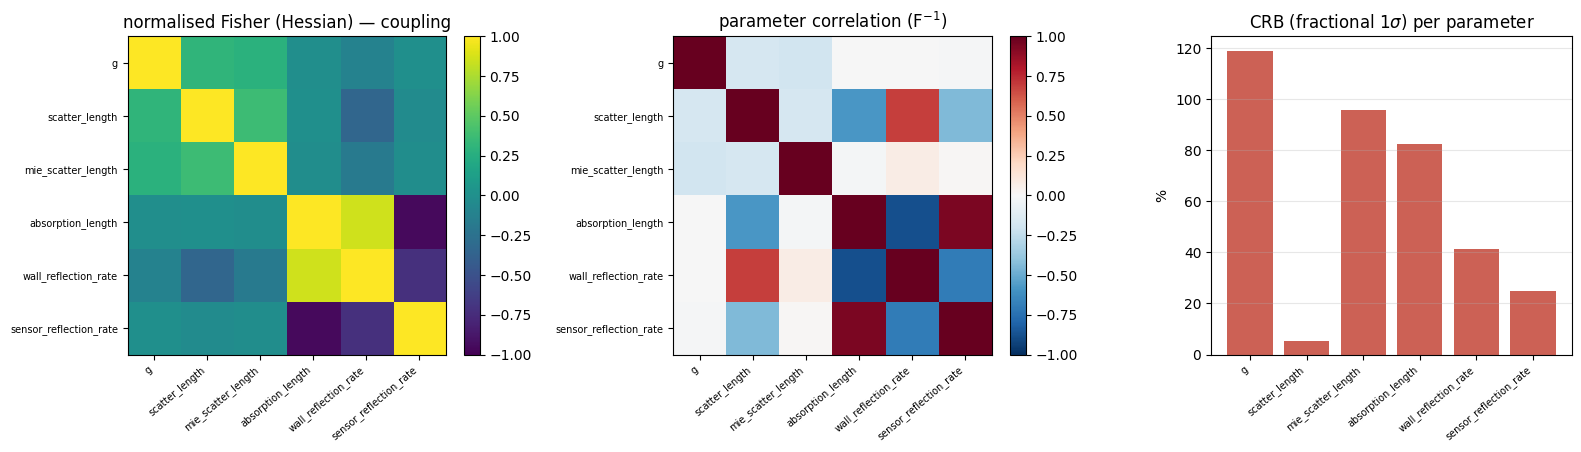

Fisher condition number: 1.2e+03  (spread of well- vs poorly-constrained directions)
strongest degeneracy: absorption_length <-> sensor_reflection_rate = +0.94


In [66]:
F, cov, sigma = r['fisher'], r['cov'], r['sigma']
Dg = np.sqrt(np.diag(cov)); corr = cov / np.outer(Dg, Dg)              # parameter correlation
Fn = F / np.sqrt(np.outer(np.diag(F), np.diag(F)))                     # normalised Fisher (coupling)
ev = np.linalg.eigvalsh(F); cond = ev.max() / ev.min()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
im0 = ax[0].imshow(Fn, cmap='viridis', vmin=-1, vmax=1)
ax[0].set_title('normalised Fisher (Hessian) — coupling'); plt.colorbar(im0, ax=ax[0], fraction=.046)
im1 = ax[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax[1].set_title(f'parameter correlation (F$^{{-1}}$)'); plt.colorbar(im1, ax=ax[1], fraction=.046)
for a in ax[:2]:
    a.set_xticks(range(len(FIELDS))); a.set_yticks(range(len(FIELDS)))
    a.set_xticklabels(FIELDS, rotation=40, ha='right', fontsize=7); a.set_yticklabels(FIELDS, fontsize=7)
ax[2].bar(range(len(FIELDS)), np.array(sigma)*100, color='#c0392b', alpha=.8)
ax[2].set_xticks(range(len(FIELDS))); ax[2].set_xticklabels(FIELDS, rotation=40, ha='right', fontsize=7)
ax[2].set_ylabel('%'); ax[2].set_title('CRB (fractional 1$\\sigma$) per parameter'); ax[2].grid(alpha=.3, axis='y')
fig.tight_layout(); plt.show()

iu = np.triu_indices(len(FIELDS), 1); k = int(np.argmax(np.abs(corr[iu])))
print(f'Fisher condition number: {cond:.1e}  (spread of well- vs poorly-constrained directions)')
print(f'strongest degeneracy: {FIELDS[iu[0][k]]} <-> {FIELDS[iu[1][k]]} = {corr[iu][k]:+.2f}')

## 3. Before and after the fit
**Before:** start from a +15% perturbed guess — off truth, high loss, on the slope of the
landscape above. **After:** `fit` descends to truth; the Hessian above gives the post-fit
uncertainty. We compare every parameter to truth and to its CRB, and watch the fit converge.

param                      truth     start       fit     err     CRB
g                          0.400     0.417     0.360  -9.9%  118.7%
scatter_length           124.300   116.005   130.882  +5.3%    5.4%
mie_scatter_length      4879.000  4251.332  2602.439 -46.7%   95.9%
absorption_length        599.300   518.386   341.049 -43.1%   82.5%
wall_reflection_rate       0.112     0.124     0.099 -12.2%   41.4%
sensor_reflection_rate     0.320     0.362     0.225 -29.7%   24.9%


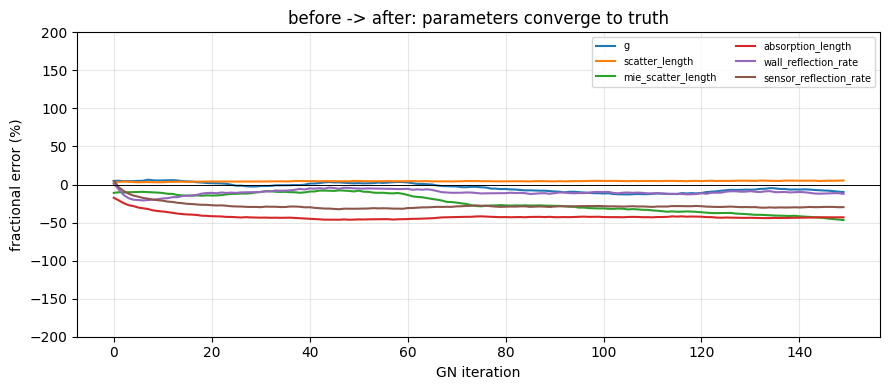


CRB is stable start->fit (near-quadratic basin): e.g. scatter_length sigma 5.4% (start) vs 5.4% (truth)


In [67]:
start, fit_theta, truth, history = r['start'], r['fit_theta'], r['truth'], r['history']

print(f'{"param":22s}{"truth":>10s}{"start":>10s}{"fit":>10s}{"err":>8s}{"CRB":>8s}')
for i, f in enumerate(FIELDS):
    e = fit_theta[i] / truth[i] - 1
    print(f'{f:22s}{truth[i]:10.3f}{start[i]:10.3f}{fit_theta[i]:10.3f}{e:+7.1%}{sigma[i]:8.1%}')

# convergence: per-parameter fractional error vs GN iteration (from fit history)
fig, ax = plt.subplots(figsize=(9, 4))
for i, f in enumerate(FIELDS):
    ax.plot(100*(history[:, i]/truth[i] - 1), label=f)
ax.axhline(0, color='k', lw=.7); ax.set(xlabel='GN iteration', ylabel='fractional error (%)',
          title='before -> after: parameters converge to truth')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=.3); ax.set_ylim(-200, 200); fig.tight_layout(); plt.show()

# before/after Hessian check: the Fisher is stable across the basin (near-quadratic loss)
sigma_at_start = r['sigma_at_start']; si = FIELDS.index('scatter_length')
print(f'\nCRB is stable start->fit (near-quadratic basin): '
      f'e.g. scatter_length sigma {sigma_at_start[si]:.1%} (start) vs {sigma[si]:.1%} (truth)')

### Profiled per-PMT gains
`fit()` solves a gain per PMT every step (k = ΣQ/ΣM over sources) and drops ∂k/∂θ from the
Jacobian. In closure every gain should be 1. Where one source supplies nearly all of a PMT's
light (a collimator spot), the gain can absorb that source's mismatch, so look for gains away
from 1 at high dominant-source share, especially collimator-dominated PMTs.

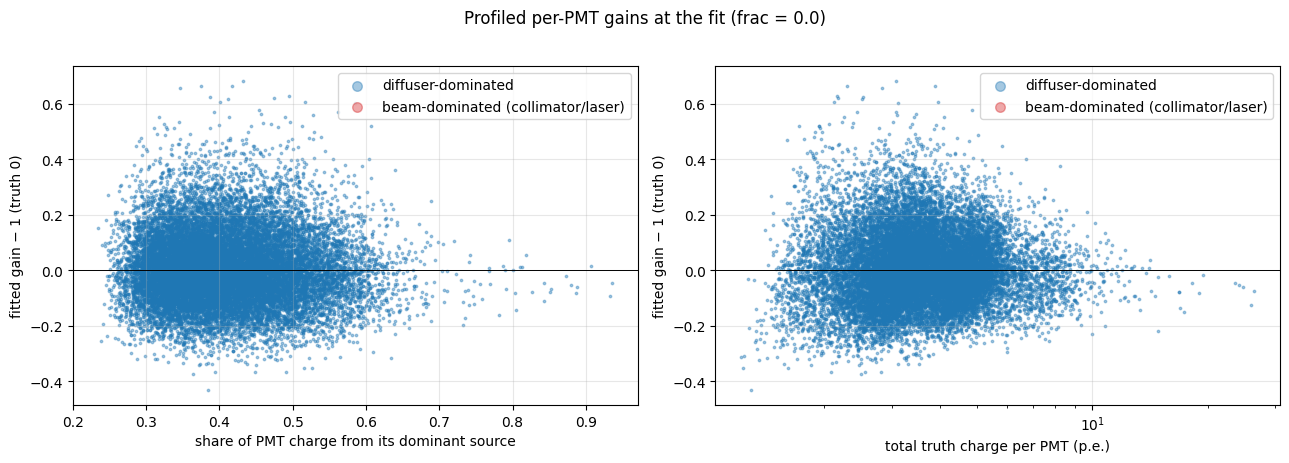

PMT group                                 n  mean k-1   rms k-1
all lit                               19746    +0.008     0.129
dominant share < 0.5                  16857    +0.010     0.129
dominant share > 0.9, diffuser            3    -0.042     0.061


In [58]:
if 'gains' not in r.files:
    print('no gains in this results file (rerun the updated job)')
else:
    k, Q = r['gains'], r['truth_charge']             # (NS,), (n_sources, NS)
    tot = Q.sum(0)
    top = Q.argmax(0)                                # dominant source per PMT
    dom = Q.max(0) / np.where(tot > 0, tot, 1)       # its share of that PMT's charge
    is_beam = np.array([source_labels[t].startswith(('col', 'las')) for t in top])
    lit = tot > 0

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    for m, c, lab in [(lit & ~is_beam, 'tab:blue', 'diffuser-dominated'),
                      (lit & is_beam, 'tab:red', 'beam-dominated (collimator/laser)')]:
        ax[0].scatter(dom[m], k[m] - 1, s=3, alpha=.4, c=c, label=lab)
        ax[1].scatter(tot[m], k[m] - 1, s=3, alpha=.4, c=c, label=lab)
    for a in ax:
        a.axhline(0, color='k', lw=.7); a.set_ylabel('fitted gain − 1 (truth 0)')
        a.grid(alpha=.3); a.legend(markerscale=4)
    ax[0].set_xlabel("share of PMT charge from its dominant source")
    ax[1].set_xscale('log'); ax[1].set_xlabel('total truth charge per PMT (p.e.)')
    fig.suptitle(f'Profiled per-PMT gains at the fit (frac = {float(r["frac"])})', y=1.02)
    fig.tight_layout(); plt.show()

    print(f'{"PMT group":36s}{"n":>7s}{"mean k-1":>10s}{"rms k-1":>10s}')
    for name, m in [('all lit', lit),
                    ('dominant share < 0.5', lit & (dom < .5)),
                    ('dominant share > 0.9, diffuser', lit & (dom > .9) & ~is_beam),
                    ('dominant share > 0.9, beam', lit & (dom > .9) & is_beam)]:
        if m.any():
            d = k[m] - 1
            print(f'{name:36s}{m.sum():7d}{d.mean():+10.3f}{np.sqrt(np.mean(d ** 2)):10.3f}')